# Extended Lab: Modeling Stock Market Data (Python edition)

This lab reproduces and extends *Chapter 4: Modeling Stock Market Data* from
*Practical Data Science Cookbook* using **Python (pandas/numpy/matplotlib)**
instead of R, since the original R packages (`XML`, `plyr`, `reshape2`,
`zoo`, `ggplot2`) map cleanly onto pandas + matplotlib.

**Why not use the original data sources directly?**
- finviz.com's screener CSV export now requires an **Elite** subscription for
  the URL-based bulk export used in the book.
- Yahoo Finance's old `ichart.finance.yahoo.com/table.csv` endpoint used in
  the book was **shut down years ago**.

So this lab uses a **synthetic but realistic dataset** generated to mimic a
raw finviz export (same messy formatting: `%`, `$`, commas, `B`/`M` suffixes)
plus a simulated price history (geometric Brownian motion), so every cell
below runs completely offline and reproducibly. Section 7 shows the code
you'd use to swap in **real** `yfinance` data when you have internet access.

**Read `00_Background_Theory.md` first** for the concepts and limitations
behind every step here.

### Lab objectives
1. Acquire a cross-sectional stock dataset (simulate a finviz export).
2. Summarize and understand the fields.
3. Clean messy numeric-as-text columns and handle an extreme outlier.
4. Compute sector/industry relative-valuation benchmarks and a composite
   "how undervalued" index.
5. Screen for a target list of stocks using multi-criteria filters.
6. Pull/simulate historical prices, compute moving averages, and visualize.


## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
np.random.seed(42)
plt.rcParams["figure.figsize"] = (9, 5)


## 1. Acquiring stock market data

In the book, this step downloads a finviz.com screener CSV export and reads
it with `read.csv`. Here we generate a synthetic dataset with the **same raw
structure** a real finviz export has: numeric fields stored as text with
`%`, `$`, commas, and `B`/`M` suffixes for market cap.

> **Using real data instead:** if you have a finviz Elite account, replace
> the generator call below with
> `finviz = pd.read_csv("https://elite.finviz.com/export.ashx?v=152&c=...&auth=YOUR_KEY")`.
> Without Elite, you can still manually export a CSV from
> https://finviz.com/screener.ashx and load it with `pd.read_csv("finviz.csv")`.


In [2]:
from data_utils import make_finviz_like_raw, simulate_price_history

finviz_raw = make_finviz_like_raw(n=400, seed=42)
finviz_raw.to_csv("finviz_raw.csv", index=False)
finviz = pd.read_csv("finviz_raw.csv")
finviz.head()


,No.,Ticker,Company,Sector,Industry,Country,Market Cap,P/E,Forward P/E,PEG,P/S,P/B,P/Cash,EPS (ttm),EPS growth next year,EPS growth next 5 years,Total Debt/Equity,Beta,Institutional Ownership,Price,Volume
0,1,WCS,Berkshire Hathaway Inc.,Financial,Property & Casualty Insurance,USA,1.39B,15.40,14.28,-,1.01,6.62,21.77,1.67,19.27%,15.61%,0.23,1.18,31.0%,"172,000.00","1,434,753"
1,2,XRU,XRU Holdings Inc.,Services,Auto Parts Stores,UK,4.57B,27.48,26.10,2.65,11.09,2.08,5.99,-0.53,14.16%,23.55%,0.45,0.58,34.4%,25.79,"1,091,512"
2,3,VLUV,VLUV Holdings Inc.,Industrial Goods,Industrial Equipment & Components,USA,120.17M,25.35,23.56,2.10,2.52,5.30,2.33,0.70,3.30%,2.33%,0.39,1.75,33.4%,44.29,"1,598,054"
3,4,COUH,COUH Holdings Inc.,Financial,Asset Management,USA,555.76M,34.87,24.65,0.10,0.81,1.31,16.44,1.86,14.90%,4.87%,0.58,1.31,47.3%,31.34,"865,007"
4,5,MSEX,MSEX Holdings Inc.,Basic Materials,Gold,USA,4.53B,31.98,26.70,1.37,1.88,0.66,2.35,-1.81,-1.97%,14.80%,0.22,0.81,87.5%,42.00,"326,063"


## 2. Summarizing the data

Equivalent of R's `head()` and `summary()`.

In [3]:
finviz[["Ticker","Company","Sector","Industry"]].head(6)


,Ticker,Company,Sector,Industry
0,WCS,Berkshire Hathaway Inc.,Financial,Property & Casualty Insurance
1,XRU,XRU Holdings Inc.,Services,Auto Parts Stores
2,VLUV,VLUV Holdings Inc.,Industrial Goods,Industrial Equipment & Components
3,COUH,COUH Holdings Inc.,Financial,Asset Management
4,MSEX,MSEX Holdings Inc.,Basic Materials,Gold
5,LXD,LXD Holdings Inc.,Healthcare,Diagnostic Substances


In [4]:
finviz.info()


<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   No.                      400 non-null    int64  
 1   Ticker                   400 non-null    str    
 2   Company                  400 non-null    str    
 3   Sector                   400 non-null    str    
 4   Industry                 400 non-null    str    
 5   Country                  400 non-null    str    
 6   Market Cap               400 non-null    str    
 7   P/E                      400 non-null    str    
 8   Forward P/E              400 non-null    str    
 9   PEG                      400 non-null    str    
 10  P/S                      400 non-null    float64
 11  P/B                      400 non-null    float64
 12  P/Cash                   400 non-null    float64
 13  EPS (ttm)                400 non-null    float64
 14  EPS growth next year     400 non-null

In [5]:
finviz.describe(include="all").T.head(10)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
No.,400.0,NaN,NaN,NaN,200.5,115.614301,1.0,100.75,200.5,300.25,400.0
Ticker,400,400,WCS,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Company,400,400,Berkshire Hathaway Inc.,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sector,400,9,Healthcare,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Industry,400,23,Diversified Utilities,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,400,4,USA,327,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Market Cap,400,367,1.04B,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
P/E,400,362,-,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Forward P/E,400,366,-,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PEG,400,218,-,46,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Field notes** (mirrors the book's "There's more..." section):
- **Price**: dollar value to purchase one share.
- **Volume**: most recent number of shares traded in a day.
- **P/E, PEG, P/S, P/B, P/Cash**: valuation multiples (see background doc §2.1).
- **Total Debt/Equity**: leverage / financial-health measure.
- **Beta**: volatility relative to the market.
- **Institutional Ownership**: % of shares held by institutions.


## 3. Cleaning and exploring the data

### 3.1 Clean messy numeric-as-text columns
Just like the book's `clean_numeric` R function using `gsub`, we strip `%`,
`$`, `,`, and convert `-` placeholders to missing, then cast to numeric.
Market Cap needs its own parser because of the `B`/`M` suffix.

In [6]:
def clean_numeric(series: pd.Series) -> pd.Series:
    """Strip %, $, commas and convert placeholder '-' to NaN, then cast to float.
    Python/pandas equivalent of the book's R `clean_numeric` (gsub-based) helper."""
    cleaned = (series.astype(str)
                      .str.replace("%", "", regex=False)
                      .str.replace("$", "", regex=False)
                      .str.replace(",", "", regex=False)
                      .str.strip())
    cleaned = cleaned.replace("-", np.nan)
    return pd.to_numeric(cleaned, errors="coerce")

def clean_market_cap(series: pd.Series) -> pd.Series:
    """Convert finviz-style '1.23B' / '456.70M' strings to a $ millions float."""
    def _conv(x):
        x = str(x).strip()
        if x.endswith("B"):
            return float(x[:-1]) * 1000
        if x.endswith("M"):
            return float(x[:-1])
        try:
            return float(x)
        except ValueError:
            return np.nan
    return series.apply(_conv)

id_cols = ["No.", "Ticker", "Company", "Sector", "Industry", "Country"]
numeric_cols = [c for c in finviz.columns if c not in id_cols + ["Market Cap"]]

finviz_clean = finviz.copy()
finviz_clean["Market Cap"] = clean_market_cap(finviz_clean["Market Cap"])
for col in numeric_cols:
    finviz_clean[col] = clean_numeric(finviz_clean[col])

finviz_clean.dtypes


No.                          int64
Ticker                         str
Company                        str
Sector                         str
Industry                       str
Country                        str
Market Cap                 float64
P/E                        float64
Forward P/E                float64
PEG                        float64
P/S                        float64
P/B                        float64
P/Cash                     float64
EPS (ttm)                  float64
EPS growth next year       float64
EPS growth next 5 years    float64
Total Debt/Equity          float64
Beta                       float64
Institutional Ownership    float64
Price                      float64
Volume                       int64
dtype: object

### 3.2 Explore the price distribution

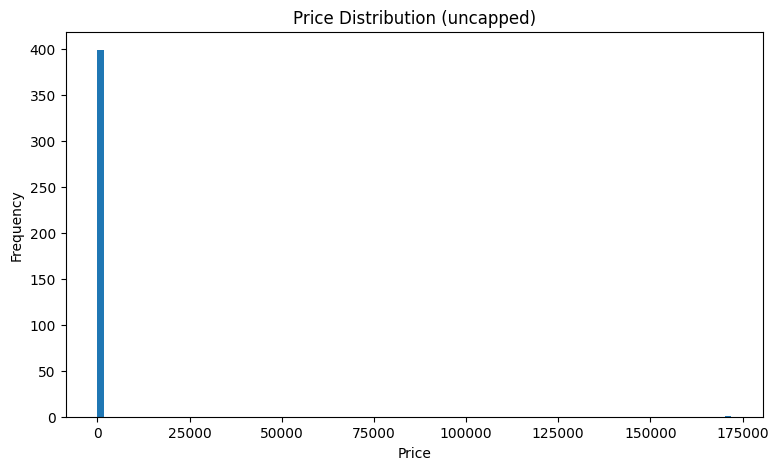

In [7]:
fig, ax = plt.subplots()
ax.hist(finviz_clean["Price"], bins=100)
ax.set_title("Price Distribution (uncapped)")
ax.set_xlabel("Price")
ax.set_ylabel("Frequency")
plt.show()


As in the book, one extreme outlier dominates the x-axis and hides the real distribution. Let's cap it.

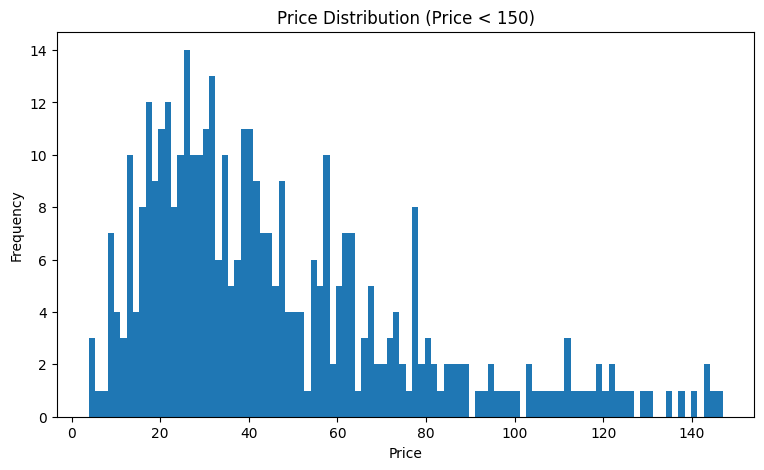

In [8]:
fig, ax = plt.subplots()
ax.hist(finviz_clean.loc[finviz_clean.Price < 150, "Price"], bins=100)
ax.set_title("Price Distribution (Price < 150)")
ax.set_xlabel("Price")
ax.set_ylabel("Frequency")
plt.show()


### 3.3 Sector average prices — and finding the outlier

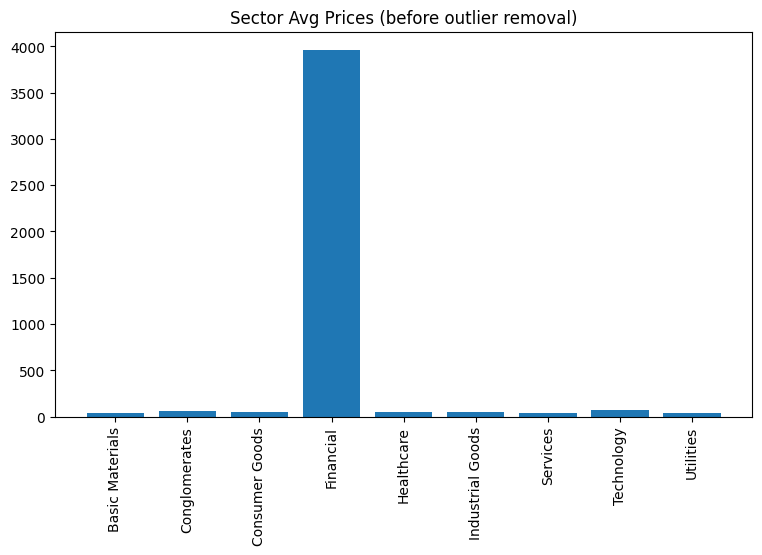

,Sector,Sector_Avg_Price
3,Financial,3961.975682
7,Technology,68.521667
1,Conglomerates,60.929524
5,Industrial Goods,54.262128
4,Healthcare,51.935600
2,Consumer Goods,48.399714
8,Utilities,42.589375
6,Services,41.789565
0,Basic Materials,39.048261


In [9]:
sector_avg_prices = (finviz_clean.groupby("Sector")["Price"]
                     .mean().rename("Sector_Avg_Price").reset_index())

fig, ax = plt.subplots()
ax.bar(sector_avg_prices.Sector, sector_avg_prices.Sector_Avg_Price)
ax.set_title("Sector Avg Prices (before outlier removal)")
plt.xticks(rotation=90)
plt.show()
sector_avg_prices.sort_values("Sector_Avg_Price", ascending=False)


In [10]:
# Drill into the sector with the highest average, then the industry, then the company
top_sector = sector_avg_prices.sort_values("Sector_Avg_Price", ascending=False).iloc[0].Sector
industry_avg = (finviz_clean[finviz_clean.Sector == top_sector]
                .groupby("Industry")["Price"].mean()
                .rename("Industry_Avg_Price").reset_index()
                .sort_values("Industry_Avg_Price", ascending=False))
industry_avg.head()


,Industry,Industry_Avg_Price
1,Property & Casualty Insurance,10164.869412
2,REIT - Office,109.996667
3,Regional Banks,42.372500
0,Asset Management,39.522222


In [11]:
top_industry = industry_avg.iloc[0].Industry
company_chart = finviz_clean[(finviz_clean.Sector == top_sector) &
                              (finviz_clean.Industry == top_industry)]
outlier_row = company_chart.loc[company_chart.Price.idxmax()]
print(f"Outlier company: {outlier_row.Company} ({outlier_row.Ticker}), "
      f"Price = {outlier_row.Price:,.2f}")


Outlier company: Berkshire Hathaway Inc. (WCS), Price = 172,000.00


Remove the outlier and re-compute the sector averages (mirrors the book's `subset(finviz, Ticker!="BRK-A")` step).

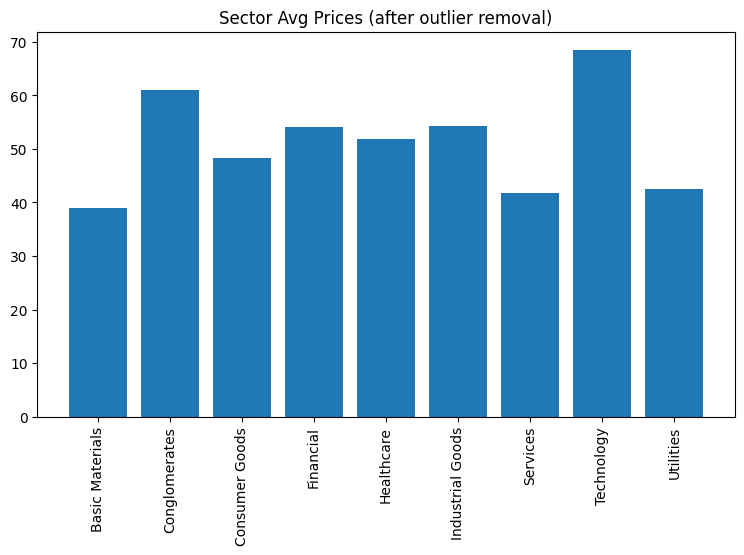

,Sector,Sector_Avg_Price
0,Basic Materials,39.048261
1,Conglomerates,60.929524
2,Consumer Goods,48.399714
3,Financial,54.114651
4,Healthcare,51.935600
5,Industrial Goods,54.262128
6,Services,41.789565
7,Technology,68.521667
8,Utilities,42.589375


In [12]:
finviz_clean = finviz_clean[finviz_clean.Ticker != outlier_row.Ticker].reset_index(drop=True)

sector_avg_prices2 = (finviz_clean.groupby("Sector")["Price"]
                      .mean().rename("Sector_Avg_Price").reset_index())
fig, ax = plt.subplots()
ax.bar(sector_avg_prices2.Sector, sector_avg_prices2.Sector_Avg_Price)
ax.set_title("Sector Avg Prices (after outlier removal)")
plt.xticks(rotation=90)
plt.show()
sector_avg_prices2


## 4. Generating relative valuations

We compute sector- and industry-level average multiples, merge them back
onto every stock, flag each stock as "under peer average" per metric, then
sum the flags into a single `RelValIndex` (0-10). See background doc §2.3
for the caveats of this simple scoring approach.

In [13]:
metrics = ["Price", "P/E", "PEG", "P/S", "P/B"]

sector_avg = (finviz_clean.groupby("Sector")[metrics].mean()
              .add_prefix("SAvg_").reset_index())
industry_avg = (finviz_clean.groupby(["Sector", "Industry"])[metrics].mean()
                .add_prefix("IAvg_").reset_index())

finviz_val = finviz_clean.merge(sector_avg, on="Sector") \
                          .merge(industry_avg, on=["Sector", "Industry"])
print(f"Rows before merge: {len(finviz_clean)}, after merge (industries with data): {len(finviz_val)}")
sector_avg.round(2)


Rows before merge: 399, after merge (industries with data): 399


,Sector,SAvg_Price,SAvg_P/E,SAvg_PEG,SAvg_P/S,SAvg_P/B
0,Basic Materials,39.05,25.88,1.96,2.74,4.56
1,Conglomerates,60.93,23.83,2.13,2.40,3.29
2,Consumer Goods,48.40,22.14,2.11,2.43,3.50
3,Financial,54.11,22.73,1.91,3.13,3.35
4,Healthcare,51.94,27.40,2.08,2.67,3.56
5,Industrial Goods,54.26,21.29,2.01,2.47,5.33
6,Services,41.79,24.35,1.83,2.74,3.73
7,Technology,68.52,21.76,2.53,2.80,4.42
8,Utilities,42.59,24.05,1.90,2.27,3.98


In [14]:
flag_cols = []
for m in metrics:
    finviz_val[f"S_{m}_Under"] = (finviz_val[m] < finviz_val[f"SAvg_{m}"]).astype(int)
    finviz_val[f"I_{m}_Under"] = (finviz_val[m] < finviz_val[f"IAvg_{m}"]).astype(int)
    flag_cols += [f"S_{m}_Under", f"I_{m}_Under"]

finviz_val["RelValIndex"] = finviz_val[flag_cols].sum(axis=1)
finviz_val["RelValIndex"].describe()


count    399.000000
mean       5.711779
std        2.064205
min        0.000000
25%        4.000000
50%        6.000000
75%        7.000000
max       10.000000
Name: RelValIndex, dtype: float64

In [15]:
potentially_undervalued = finviz_val[finviz_val.RelValIndex >= 8] \
                              .sort_values("RelValIndex", ascending=False)
potentially_undervalued[["Ticker", "Company", "Sector", "RelValIndex"]].head(15)


,Ticker,Company,Sector,RelValIndex
4,LXD,LXD Holdings Inc.,Healthcare,10
75,SVT,SVT Holdings Inc.,Services,10
85,FDC,FDC Holdings Inc.,Healthcare,10
41,GDB,GDB Holdings Inc.,Healthcare,10
53,WUC,WUC Holdings Inc.,Services,10
367,JCKS,JCKS Holdings Inc.,Services,10
356,NKK,NKK Holdings Inc.,Basic Materials,10
354,RWXA,RWXA Holdings Inc.,Utilities,10
274,GMPO,GMPO Holdings Inc.,Industrial Goods,10
336,OET,OET Holdings Inc.,Healthcare,10


## 5. Screening stocks and analyzing historical prices

### 5.1 Apply screening criteria
Same criteria as the book, translated to pandas boolean filtering:
- Price between \$20 and \$100
- Volume > 10,000
- Positive EPS (trailing, next year, next 5 years)
- Total Debt/Equity < 1
- Beta < 1.5
- Institutional Ownership < 30%
- RelValIndex >= 8


In [16]:
target_stocks = finviz_val[
    (finviz_val.Price.between(20, 100)) &
    (finviz_val.Volume > 10_000) &
    (finviz_val.Country == "USA") &
    (finviz_val["EPS (ttm)"] > 0) &
    (finviz_val["EPS growth next year"] > 0) &
    (finviz_val["EPS growth next 5 years"] > 0) &
    (finviz_val["Total Debt/Equity"] < 1) &
    (finviz_val.Beta < 1.5) &
    (finviz_val["Institutional Ownership"] < 30) &
    (finviz_val.RelValIndex >= 8)
].sort_values("RelValIndex", ascending=False)

print(f"Target list size: {len(target_stocks)}")
target_stocks[["Ticker", "Company", "RelValIndex"]]


Target list size: 3


,Ticker,Company,RelValIndex
41,GDB,GDB Holdings Inc.,10
111,CBW,CBW Holdings Inc.,10
371,YILO,YILO Holdings Inc.,8


In [17]:
# Keep the analysis manageable: cap the target list at 6 tickers (like the book)
target_tickers = target_stocks.Ticker.head(6).tolist()
if len(target_tickers) < 3:
    # fall back so the rest of the notebook always has something to plot
    target_tickers = finviz_val.sort_values("RelValIndex", ascending=False).Ticker.head(6).tolist()
target_tickers


['GDB', 'CBW', 'YILO']

### 5.2 Historical prices and moving averages

> **Real data note:** the book pulls history from Yahoo's defunct
> `ichart.finance.yahoo.com` endpoint. Section 7 shows the modern
> `yfinance` equivalent. Here we **simulate** daily prices with geometric
> Brownian motion so the notebook runs offline.

In [18]:
stocks = simulate_price_history(target_tickers, start="2018-01-01", end="2023-12-29", seed=7)

# 50-day and 200-day simple moving averages, per symbol (equivalent of R's rollmean via zoo)
stocks["MovAvg50"] = stocks.groupby("Symbol")["AdjClose"].transform(lambda s: s.rolling(50).mean())
stocks["MovAvg200"] = stocks.groupby("Symbol")["AdjClose"].transform(lambda s: s.rolling(200).mean())
stocks.dropna().head()


,Symbol,Date,Open,High,Low,Close,Volume,AdjClose,MovAvg50,MovAvg200
199,GDB,2018-10-05,35.44,35.69,35.31,35.56,1407390,35.56,32.5860,41.59785
200,GDB,2018-10-08,36.37,36.62,36.08,36.33,545572,36.33,32.5962,41.47655
201,GDB,2018-10-09,38.04,38.29,37.78,38.03,2157126,38.03,32.6466,41.36690
202,GDB,2018-10-10,39.34,39.73,39.03,39.43,1777646,39.43,32.7298,41.27125
203,GDB,2018-10-11,38.33,38.56,38.14,38.37,993650,38.37,32.8146,41.16975


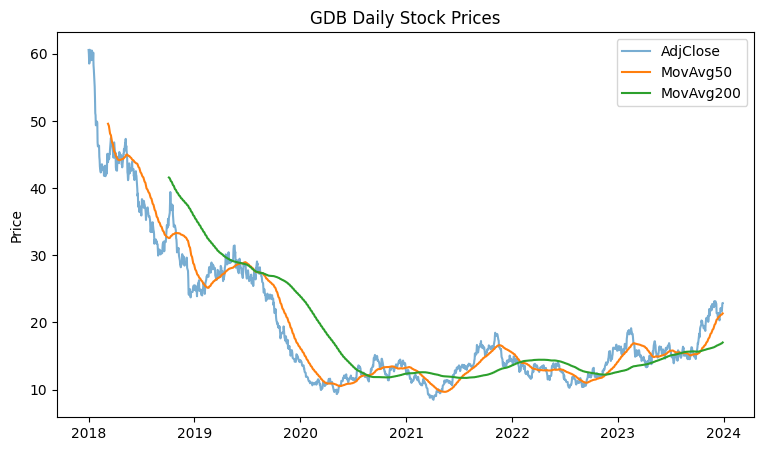

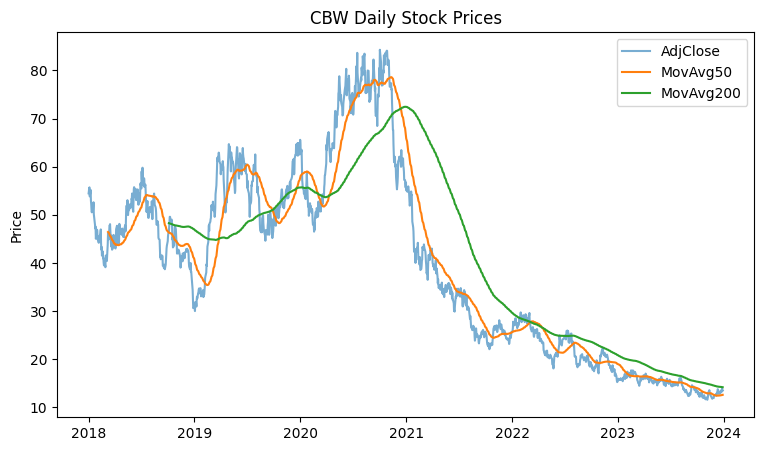

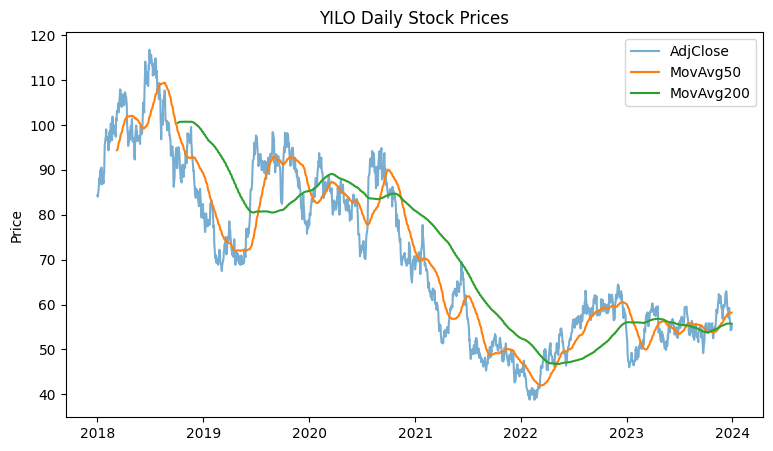

In [19]:
# Per-symbol price + moving average chart
for sym in target_tickers:
    sdata = stocks[stocks.Symbol == sym]
    fig, ax = plt.subplots()
    ax.plot(sdata.Date, sdata.AdjClose, label="AdjClose", alpha=0.6)
    ax.plot(sdata.Date, sdata.MovAvg50, label="MovAvg50")
    ax.plot(sdata.Date, sdata.MovAvg200, label="MovAvg200")
    ax.set_title(f"{sym} Daily Stock Prices")
    ax.set_ylabel("Price")
    ax.legend()
    plt.show()


### 5.3 Combined price comparison across the target list

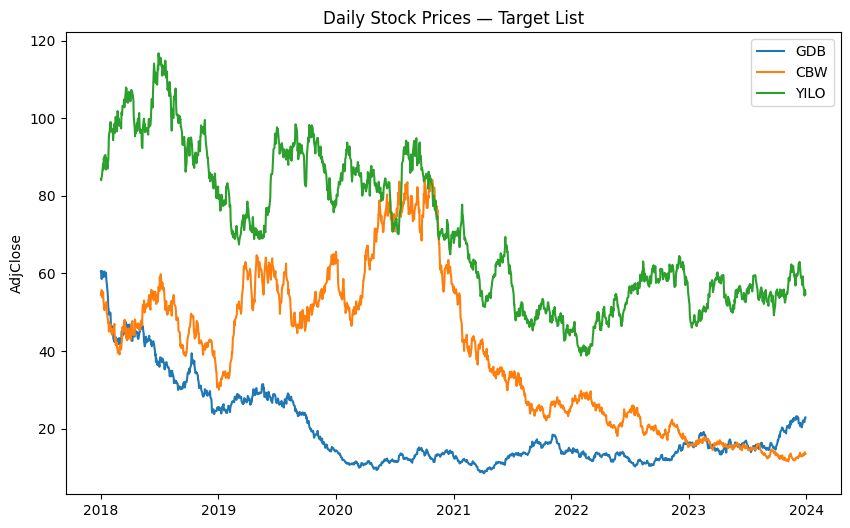

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
for sym in target_tickers:
    sdata = stocks[stocks.Symbol == sym]
    ax.plot(sdata.Date, sdata.AdjClose, label=sym)
ax.set_title("Daily Stock Prices — Target List")
ax.set_ylabel("AdjClose")
ax.legend()
plt.show()


### 5.4 Open/High/Low/Close summary

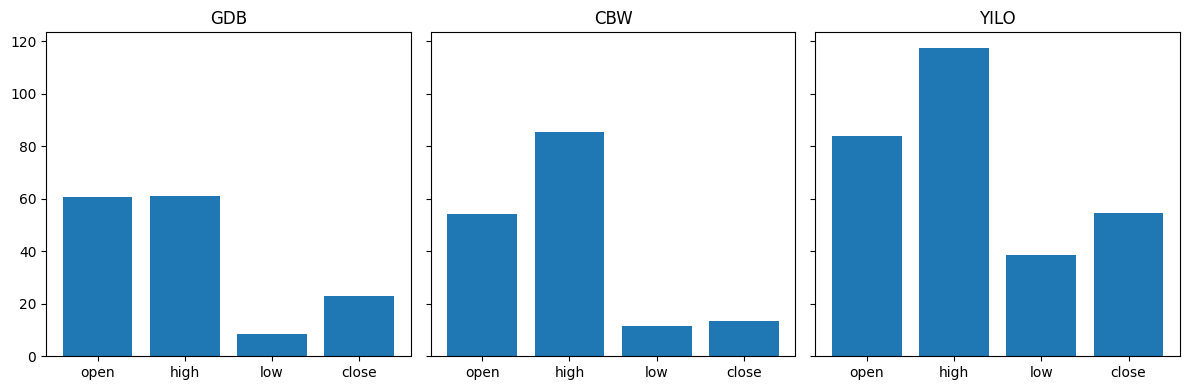

,Symbol,open,high,low,close
0,CBW,54.21,85.50,11.54,13.50
1,GDB,60.72,61.21,8.45,22.89
2,YILO,83.90,117.59,38.42,54.64


In [21]:
price_summaries = stocks.groupby("Symbol").agg(
    open=("Open", "first"), high=("High", "max"),
    low=("Low", "min"), close=("AdjClose", "last")
).reset_index()

summary_long = price_summaries.melt(id_vars="Symbol", var_name="stat", value_name="value")

fig, axes = plt.subplots(1, len(target_tickers), figsize=(4*len(target_tickers), 4), sharey=True)
for ax, sym in zip(axes, target_tickers):
    sub = summary_long[summary_long.Symbol == sym]
    ax.bar(sub["stat"], sub["value"])
    ax.set_title(sym)
plt.tight_layout()
plt.show()
price_summaries


## 6. How it works — interpreting the results

- **Volatility comparison**: symbols whose lines swing widely on the combined
  chart, or whose high/low bars are far apart in the summary chart, have been
  more volatile over the period.
- **Trend via moving averages**: a 50-day MA consistently above the 200-day
  MA and rising suggests an established uptrend; the reverse suggests a
  downtrend. Treat this as descriptive, not predictive (see background §5).
- **RelValIndex** only tells you how a stock's multiples compare to *this
  dataset's* peers on *this day* — it is not a valuation estimate and doesn't
  account for growth quality, balance-sheet risk beyond D/E, or macro
  conditions.


## 7. Getting real data (reference only — requires outbound internet)

```python
# Real historical prices via yfinance (pip install yfinance)
import yfinance as yf
real_hist = yf.download(target_tickers, start="2018-01-01", end="2023-12-29")

# Real finviz export (requires a finviz Elite subscription for the bulk CSV URL)
finviz_real = pd.read_csv(
    "https://elite.finviz.com/export.ashx?v=152&c=0,1,2,...,68&auth=YOUR_AUTH_TOKEN"
)

# Free-tier fundamentals alternative for a handful of tickers at a time:
info = yf.Ticker("AAPL").info  # dict with trailingPE, forwardPE, priceToSalesTrailing12Months, etc.
```

None of the above will run in this sandboxed environment (no outbound access
to finance data hosts), but it will work in a normal local Python
environment with internet access.


## 8. Exercises

1. Add a **median**-based sector benchmark alongside the mean and compare how
   many stocks get flagged as undervalued under each.
2. Add an **ROE** (return on equity) quality filter to the screening step —
   simulate a plausible `ROE` column and require it above a threshold.
3. Change the relative-valuation weighting so P/E and Forward P/E together
   only count once (they're highly correlated) — does the target list change?
4. Re-run the whole notebook with a different `seed` in `make_finviz_like_raw`
   and `simulate_price_history` and compare the resulting target list.
5. Plot a correlation heatmap of daily returns across the target tickers —
   are they truly diversified, or do they move together?
